In [1]:
# parameters
group = None  # This will get overwritten by papermill

In [2]:
# Parameters
group = "AtrialCardiomyocytes"


In [3]:
print(group)

AtrialCardiomyocytes


# Import modules

In [4]:
# import warnings
# warnings.simplefilter("ignore", UserWarning)

import anndata
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import numpy.random as random
import pandas as pd
import scanpy as sc

import scvi

/home/kk837/.conda/envs/scvi_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import gc
import torch

In [6]:
import session_info
session_info.show()

/home/kk837/.conda/envs/scvi_env/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [7]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, facecolor='white', color_map = 'RdPu',)

# Variables

In [8]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'

In [9]:
import os
os.makedirs(f'{data_object_dir}/scVI/models', exist_ok=True)
os.makedirs(f'{data_object_dir}/scVI/latent_variables', exist_ok=True)

# Read in anndata

In [10]:
adata = sc.read_h5ad(f'{data_object_dir}/b2c_cells_{group}_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 34193 × 18077
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_tacco_ref-hd-scn_colors', 'donor_colors', 'library_colors', 'neighbors', 'umap

# Run scVI, categorical covariates to correct: donor+region

##### 3 #####


Anndata setup with scvi-tools version 1.3.3.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'donor',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   3   │
│         n_cells          │ 34193 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 18077 │
└──────────────────────────┴───────┘

...

Epoch 400/400: 100%|██████████| 400/400 [16:48<00:00,  2.47s/it, v_num=1, train_loss_step=3.03e+3, train_loss_epoch=3.11e+3]

Epoch 400/400: 100%|██████████| 400/400 [16:48<00:00,  2.47s/it, v_num=1, train_loss_step=2.97e+3, train_loss_epoch=3.11e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [16:48<00:00,  2.52s/it, v_num=1, train_loss_step=2.97e+3, train_loss_epoch=3.11e+3]

/home/kk837/.conda/envs/scvi_env/lib/python3.12/site-packages/anndata/_core/anndata.py:774: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['HEA_FOET14880396___1527', 'HEA_FOET14880396___3573', 'HEA_FOET14880396___3598', 'HEA_FOET14880396___3678', 'HEA_FOET14880396___3834']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


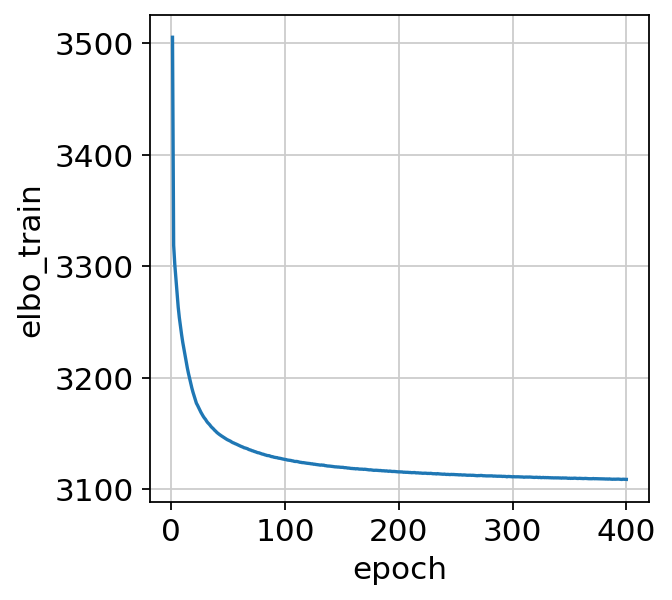

In [11]:
# Setup anndata for scVI
scvi.model.SCVI.setup_anndata(adata, 
                              # layer="counts", 
                              batch_key="donor", # we want to correct for this 
                              # continuous_covariate_keys=['total_counts','pct_counts_mt','pct_counts_ribo']
                             ) 

# with three n_layer conditions
n_layer_list = [3]

for n_layers in n_layer_list:
    print(f'##### {n_layers} #####')
    # setup
    vae = scvi.model.SCVI(adata, n_hidden = 128, n_latent = 50, n_layers = n_layers, dispersion = 'gene-batch')
    vae.view_anndata_setup(adata)
    # train
    vae.train(max_epochs=400)
    # save trained model
    vae.save(f"{data_object_dir}/scVI/models/b2c_cells_{group}_correcting-donor_n-layers-{str(n_layers)}/",
             overwrite=True)
    # save latent space
    latent = sc.AnnData(vae.get_latent_representation(),
                    obs=adata.obs.copy())
    # drop all the obs columns, for simplicity
    latent.obs = latent.obs.drop(columns=latent.obs.columns, axis=1)
    latent.write(f'{data_object_dir}/scVI/latent_variables/b2c_cells_{group}_correcting-donor_n-layers-{str(n_layers)}.h5ad')
    # Convergency plot
    vae.history['elbo_train']
    x = np.linspace(1, (len(vae.history['elbo_train'])), (len(vae.history['elbo_train'])))
    plt.plot(x, vae.history['elbo_train'], label="train")
    plt.xlabel('epoch')
    plt.ylabel('elbo_train')
    plt.show()
    
    del vae
    # free up GPU
    gc.collect()
    torch.cuda.empty_cache()
    print('')